In [11]:
import DifferentialEquations as DE

## Introduction to two dimensional system

We will study system of the form

$$
\begin{split}
  \frac{dx}{dt} = \dot{x} & = ax + by \\
  \frac{dy}{dt} = \dot{y} & = cx + dy 
\end{split}
$$

or equivalently,

$$
\begin{pmatrix}
  \dot{x}  \\
  \dot{y}  
\end{pmatrix} = \begin{pmatrix}
a & b \\
c & d
\end{pmatrix} \begin{pmatrix}
  x  \\
  y  
\end{pmatrix}.
$$

We can write the above in the matrix-vector notation as below,

$$
\dot{X} = AX
$$

where X = $\begin{pmatrix}
  x  \\
  y  
\end{pmatrix}$ and A = $\begin{pmatrix}
a & b \\
c & d
\end{pmatrix}$ 


In the first example, we will consider A to be of the shape $\begin{pmatrix}
p & 0 \\
0 & -1
\end{pmatrix}$ where we will systematically vary the value of p. Here, we can solve them easily to yield

$$
\begin{align*}
x(t)  &= x_0{e^{pt}} \\
y(t)  &= y_0{e^{-t}}
\end{align*}.
$$

$x_0$, $y_0$ are initial conditions, i.e, $x(0) = x_0$ and $y(0) = y_0$.



In [2]:
## Define the RHS of the ODE
function twoDlinear!(du, u, p, t)
      du[1] = p * u[1]
      du[2] = - u[2]
end


twoDlinear! (generic function with 1 method)

In [12]:
using CairoMakie

In [4]:
function portrait_withAnArrow(ax, f!, init, param, arrowpos, xory)

      
      p = param

      tspan = (0.0,10.0)
      #prob = DE.ODEProblem(f!, init, tspan, p)

      #sol = DE.solve(prob)
      #x = getindex.(sol.u, 1)
      #y = getindex.(sol.u, 2)

      times = LinRange(tspan[1], tspan[2], 40)
      x = init[1]*exp.(p*times)
      y = init[2]*exp.(-times)
    
    
      if xory==0
          ind = argmin(abs.(x .- arrowpos))
      elseif xory==1
          ind = argmin(abs.(y .- arrowpos))
      else 
          phase = arrowpos
          rad_init = sqrt(x[1]^2 + y[1]^2)
          rad_ar = rad_init*0.5 
          x_arrowpos = rad_ar * cos(phase)
          ind = argmin(abs.(x .- x_arrowpos))
      end
      ar_xpos = x[ind]
      ar_ypos = y[ind]
      
      du = [0.0,0.0]
      f!(du, [ar_xpos, ar_ypos], p, 0.0)
      
      lines!(ax, x, y, color=:black,alpha=0.7)
      factor = 0.1
      
      arrows2d!(ax, [ar_xpos], [ar_ypos], [du[1]*factor], [du[2]*factor], tipwidth=15, tiplength=5, color=:black)
      
  end


portrait_withAnArrow (generic function with 1 method)

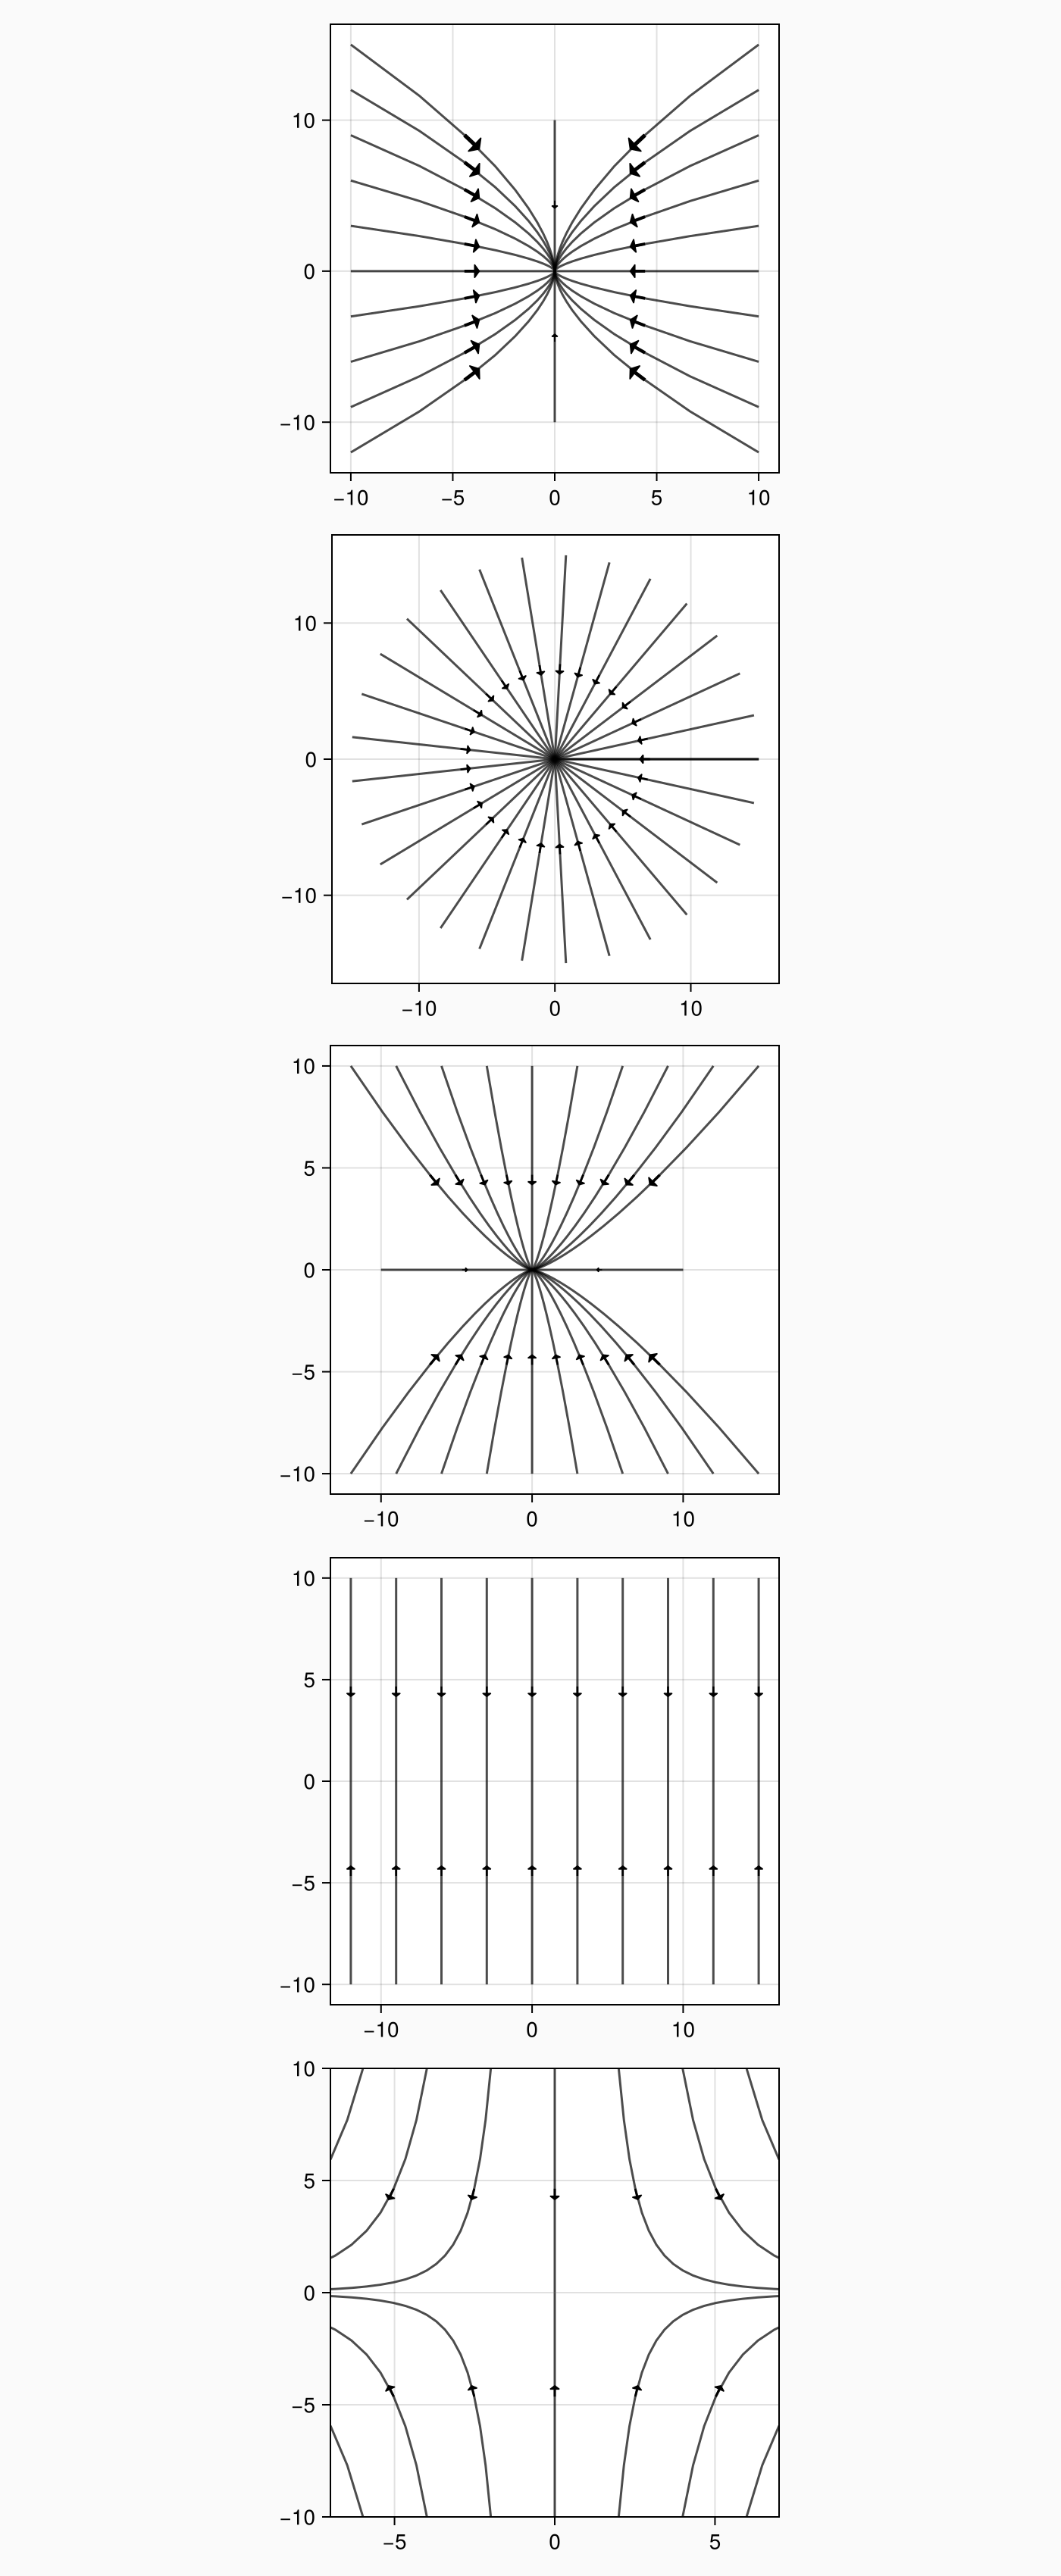

In [5]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (700, 1700))

gax_main = fig[1,1] = GridLayout()
ga = gax_main[1,1] =  GridLayout()
gb = gax_main[2,1]  = GridLayout()
gc = gax_main[3,1] = GridLayout()
gd = gax_main[4,1] = GridLayout()
ge = gax_main[5,1] = GridLayout()

gax = Axis(ga[1,1], aspect=AxisAspect(1))
gbx = Axis(gb[1,1], aspect=DataAspect())
gcx = Axis(gc[1,1], aspect=AxisAspect(1))
gdx = Axis(gd[1,1], aspect=AxisAspect(1))
gex = Axis(ge[1,1], aspect=AxisAspect(1))


## Plotting with gax axis. 
u0 = [0.0, 10.0]
p = -1.6

portrait_withAnArrow(gax, twoDlinear!, u0, p, 5, 1)


u0 = [0.0, -10.0]

portrait_withAnArrow(gax, twoDlinear!, u0, p, -5, 1)


num_initconds = 10
start_y = -15
end_y =  15
step_y = (end_y - start_y)/num_initconds

for i = 1:10
    y_now = start_y + step_y*i
    u0 = [10.0, y_now]
    portrait_withAnArrow(gax, twoDlinear!, u0, p, 5, 0)
end

  num_initconds = 10
  start_y = -15
  end_y =  15
  step_y = (end_y - start_y)/num_initconds

  for i = 1:10
      y_now = start_y + step_y*i
      u0 = [-10.0, y_now]
      portrait_withAnArrow(gax, twoDlinear!, u0, p, -5, 0)
  end


##Plotting with gbx



p = -1.0
num_initconds = 30
radius_init =  15.0



for phase_init in LinRange(0.0,2pi,num_initconds)
    x_now = radius_init * cos(phase_init)
    y_now = radius_init * sin(phase_init)
    u0 = [x_now, y_now]
    portrait_withAnArrow(gbx, twoDlinear!, u0, p, phase_init, 2)
end


##Plotting with gcx


u0 = [10.0, 0.0]
p = -0.75

portrait_withAnArrow(gcx, twoDlinear!, u0, p, 5, 0)


u0 = [-10.0, 0.0]

portrait_withAnArrow(gcx, twoDlinear!, u0, p, -5, 0)


num_initconds = 10
start_x = -15
end_x =  15
step_x = (end_x - start_x)/num_initconds

for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, 10.0]
    portrait_withAnArrow(gcx, twoDlinear!, u0, p, 5, 1)
end



for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, -10.0]
    portrait_withAnArrow(gcx, twoDlinear!, u0, p, -5, 1)
end

##Plotting with gdx
p = 0.0
num_initconds = 10
start_x = -15
end_x =  15
step_x = (end_x - start_x)/num_initconds

for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, 10.0]
    portrait_withAnArrow(gdx, twoDlinear!, u0, p, 5, 1)
end



for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, -10.0]
    portrait_withAnArrow(gdx, twoDlinear!, u0, p, -5, 1)
end




##Plotting with gex
p = 0.3
num_initconds = 10
start_x = -5
end_x =  5
step_x = (end_x - start_x)/num_initconds

for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, 100.0]
    portrait_withAnArrow(gex, twoDlinear!, u0, p, 5, 1)
end



for i = 1:10
    x_now = start_x + step_x*i
    u0 = [x_now, -100.0]
    portrait_withAnArrow(gex, twoDlinear!, u0, p, -5, 1)
end

xlims!(gex, -7, 7)
ylims!(gex, -10, 10)

fig

## Linear Algebra: Basics

### Matrix multiplication as transformation


In [6]:
A = Matrix([5/4 3/4; 3/4 5/4])

2×2 Matrix{Float64}:
 1.25  0.75
 0.75  1.25

In [7]:
using LinearAlgebra

In [8]:
eigvals(A)

2-element Vector{Float64}:
 0.5
 2.0

In [69]:
eigvecs(A)[1,:]

2-element Vector{Float64}:
 -0.7071067811865475
  0.7071067811865475

Let's call the eigenvalues of A, $\lambda1$(=0.5) and $\lambda2$(=2.0) 

In [15]:
range_points = LinRange(-10,10,10)

10-element LinRange{Float64, Int64}:
 -10.0, -7.77778, -5.55556, -3.33333, …, 3.33333, 5.55556, 7.77778, 10.0

In [16]:
lattice_points = [[x,y] for x in  range_points for y in range_points]

100-element Vector{Vector{Float64}}:
 [-10.0, -10.0]
 [-10.0, -7.777777777777779]
 [-10.0, -5.555555555555555]
 [-10.0, -3.333333333333335]
 [-10.0, -1.1111111111111107]
 [-10.0, 1.1111111111111107]
 [-10.0, 3.333333333333332]
 [-10.0, 5.555555555555555]
 [-10.0, 7.777777777777778]
 [-10.0, 10.0]
 [-7.777777777777779, -10.0]
 [-7.777777777777779, -7.777777777777779]
 [-7.777777777777779, -5.555555555555555]
 ⋮
 [7.777777777777778, 7.777777777777778]
 [7.777777777777778, 10.0]
 [10.0, -10.0]
 [10.0, -7.777777777777779]
 [10.0, -5.555555555555555]
 [10.0, -3.333333333333335]
 [10.0, -1.1111111111111107]
 [10.0, 1.1111111111111107]
 [10.0, 3.333333333333332]
 [10.0, 5.555555555555555]
 [10.0, 7.777777777777778]
 [10.0, 10.0]

In [17]:
lattice = hcat(lattice_points...)

2×100 Matrix{Float64}:
 -10.0  -10.0      -10.0      …  10.0      10.0      10.0      10.0
 -10.0   -7.77778   -5.55556      3.33333   5.55556   7.77778  10.0

In [19]:
lattice_transformed = A * lattice

2×100 Matrix{Float64}:
 -20.0  -18.3333  -16.6667  -15.0     …  15.0     16.6667  18.3333  20.0
 -20.0  -17.2222  -14.4444  -11.6667     11.6667  14.4444  17.2222  20.0

In [41]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (300, 300))
ax = Axis(fig[1,1])
scatter!(ax, lattice_transformed[1,:], lattice_transformed[2,:], color=:black)

Scatter{Tuple{Vector{Point{2, Float64}}}}

In [42]:
scatter!(ax, lattice[1,:], lattice[2,:], color=:black, alpha=0.5)

Scatter{Tuple{Vector{Point{2, Float64}}}}

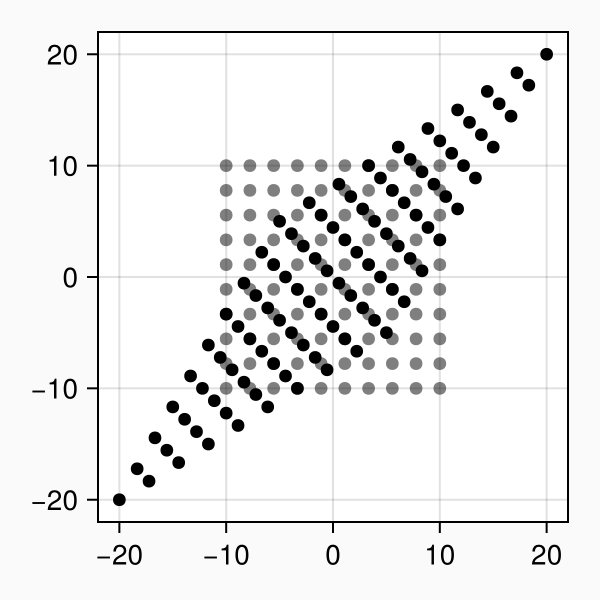

In [43]:
fig

![Allometry](https://upload.wikimedia.org/wikipedia/commons/e/e9/Transformation_of_Argyropelecus_olfersi_into_Sternoptyx_diaphana.jpg)

 "Among the fishes we discover a great variety of deformations, some of them of a very simple kind, while others are more striking and more unexpected. A comparatively simple case, involving a simple shear, is illustrated by Figs. 373 and 374. Fig. 373 represents, within Cartesian co-ordinates, a certain little oceanic fish known as Argyropelecus olfersi. Fig. 374 represents precisely the same outline, transferred to a system of oblique co-ordinates whose axes are inclined at an angle of 70°; but this is now (as far as can be seen on the scale of the drawing) a very good figure of an allied fish, assigned to a different genus, under the name of Sternoptyx diaphana. Thompson 1917, pages 748–749"

As quoted in the following wikipedia article:
[Wikipedia – On Growth and Form](https://en.wikipedia.org/wiki/On_Growth_and_Form)

### Eigenvectors and Eigenvalues

The lines in the figure below represents the two eigenvector directions. Any points along these lines, ater transformation by the matrix A (or after transformation A), will stay put on the same line they started with. As we also notice, there is a stretching and shrinking along these respective directions. The amount by which they are stretched or shrunk is given by the respective eigenvalues.

or in math lingo,

$$\begin{split}
Av1 = \lambda1v1 \\\\
Av2 = \lambda2v2
\end{split}$$

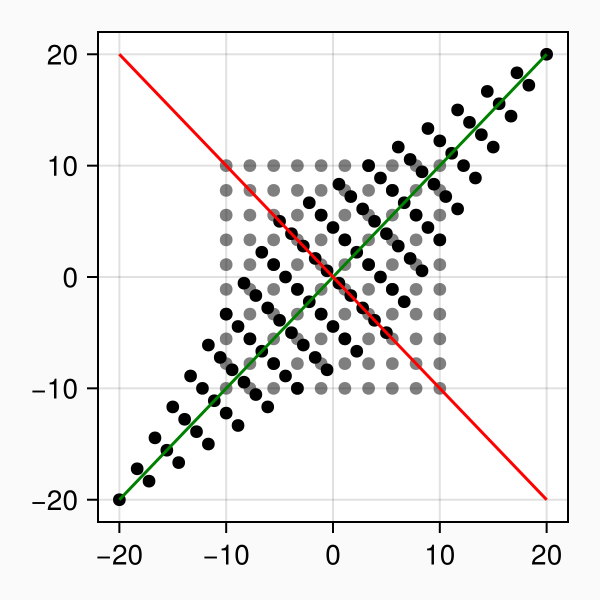

In [44]:
fig = Figure(backgroundcolor = RGBf(0.98, 0.98, 0.98),
    size = (300, 300))
ax = Axis(fig[1,1])
scatter!(ax, lattice_transformed[1,:], lattice_transformed[2,:], color=:black)
scatter!(ax, lattice[1,:], lattice[2,:], color=:black, alpha=0.5)
x = -20:20
lines!(ax, x, x, color=:green)
lines!(ax, x, -x, color=:red)
fig

Any arbitrary vector from the plane (R2) can be represented as a linear combination of these two eigenvectors, i.e, any $v= c1v1 + c2v2$

In [73]:
function give_me_cs(v)
    eigvs = eigvecs(A)
    v1 = eigvs[1,:]
    v2 = eigvs[2,:]
    c1 = transpose(v)*v1/(sqrt(v1[1]^2+v1[2]^2))
    c2 = transpose(v)*v2/(sqrt(v2[1]^2+v2[2]^2))
    (c1,c2)
end

give_me_cs (generic function with 1 method)

In [76]:
c1, c2 = give_me_cs([2,3])

(0.7071067811865476, 3.5355339059327378)

In [77]:
eigvs = eigvecs(A)
c1*eigvs[1,:] + c2*eigvs[2,:]

2-element Vector{Float64}:
 2.0
 3.0